# MNIST Autoencoder & Classifier from Scratch
This notebook contains the implementation of a 4-layer Autoencoder from scratch using NumPy, followed by a Feedforward Classifier trained on the learned latent spaces.

## 1. Data Loading and Preprocessing
Reading the MNIST binary dataset, flattening images to 784-dimensional vectors, and normalizing pixel values to [0, 1].

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct

def read_images(filename):
    with open(filename, 'rb') as f:
        _, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(num_images, rows, cols)
    return data

def read_labels(filename):
    with open(filename, 'rb') as f:
        _, num_items = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Load raw MNIST data
X_train_raw = read_images("./Data/train-images.idx3-ubyte")
y_train_raw = read_labels("./Data/train-labels.idx1-ubyte")
X_test_raw  = read_images("./Data/t10k-images.idx3-ubyte")
y_test_raw  = read_labels("./Data/t10k-labels.idx1-ubyte")

print(f"Train images shape: {X_train_raw.shape}")
print(f"Test images shape: {X_test_raw.shape}")

# Preprocessing: Flatten + Normalize
def preprocess_data(images):
    num_images = images.shape[0]
    flattened = images.reshape(num_images, 784) / 255.0
    return flattened

X_train = preprocess_data(X_train_raw)
X_test = preprocess_data(X_test_raw)

Train images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


## 2. ReluAutoencoder Class (NumPy Scratch Implementation)
Implementing the Autoencoder network with He initialization, manual forward pass, and analytical backpropagation.

In [2]:
class ReluAutoencoder:
    def __init__(self, latent_dim):
        self.input_dim = 784
        self.hidden_dim = 128
        self.latent_dim = latent_dim
        
        # He initialization
        self.W1 = np.random.randn(self.input_dim, self.hidden_dim) * np.sqrt(2. / self.input_dim)
        self.b1 = np.zeros((1, self.hidden_dim))
        
        self.W2 = np.random.randn(self.hidden_dim, self.latent_dim) * np.sqrt(2. / self.hidden_dim)
        self.b2 = np.zeros((1, self.latent_dim))
        
        self.W3 = np.random.randn(self.latent_dim, self.hidden_dim) * np.sqrt(2. / self.latent_dim)
        self.b3 = np.zeros((1, self.hidden_dim))
        
        self.W4 = np.random.randn(self.hidden_dim, self.input_dim) * np.sqrt(2. / self.hidden_dim)
        self.b4 = np.zeros((1, self.input_dim))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def sigmoid_deriv(self, A):
        return A * (1 - A)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.relu(self.Z2)   # Latent Space
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.relu(self.Z3)
        self.Z4 = np.dot(self.A3, self.W4) + self.b4
        self.A4 = self.sigmoid(self.Z4)   # Output
        return self.A4

    def get_latent(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.relu(Z2)
        return A2

    def backward(self, X, lr):
        m = X.shape[0]
        dA4 = (2.0 / m) * (self.A4 - X)
        dZ4 = dA4 * self.sigmoid_deriv(self.A4)
        dW4 = np.dot(self.A3.T, dZ4)
        db4 = np.sum(dZ4, axis=0, keepdims=True)

        dA3 = np.dot(dZ4, self.W4.T)
        dZ3 = dA3 * self.relu_derivative(self.Z3)
        dW3 = np.dot(self.A2.T, dZ3)
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * self.relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        self.W4 -= lr * dW4
        self.b4 -= lr * db4
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train(self, X, epochs, batch_size, lr):
        m = X.shape[0]
        history = []
        print(f"Training Autoencoder (latent={self.latent_dim}) ...")
        for epoch in range(epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            epoch_loss = 0
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                out = self.forward(X_batch)
                loss = np.mean((out - X_batch)**2)
                epoch_loss += loss * X_batch.shape[0]
                self.backward(X_batch, lr)
            epoch_loss /= m
            history.append(epoch_loss)
            if (epoch+1) % 5 == 0 or epoch == 0:
                print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f}")
        return history

## 3. Training Autoencoders (Latent Dims = 4 and 8)
Training both models for 20 epochs using Mean Squared Error (MSE).

In [3]:
epochs = 20
batch = 64
lr = 0.01

auto4 = ReluAutoencoder(latent_dim=4)
loss4 = auto4.train(X_train, epochs, batch, lr)

auto8 = ReluAutoencoder(latent_dim=8)
loss8 = auto8.train(X_train, epochs, batch, lr)

Training Autoencoder (latent=4) ...
Epoch 1/20 - Loss: 0.075681
Epoch 5/20 - Loss: 0.041814
Epoch 10/20 - Loss: 0.036411
Epoch 15/20 - Loss: 0.034390
Epoch 20/20 - Loss: 0.033295
Training Autoencoder (latent=8) ...
Epoch 1/20 - Loss: 0.073289
Epoch 5/20 - Loss: 0.036710
Epoch 10/20 - Loss: 0.030943
Epoch 15/20 - Loss: 0.027955
Epoch 20/20 - Loss: 0.025411


## 4. Classifiers for Latent Space Features
Defining the Classifier architectures (8 -> 4 -> ReLU -> 10 and 4 -> 10) with Cross-Entropy Loss to classify MNIST digits from the frozen encoder outputs.

In [4]:
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def one_hot(labels, num_classes=10):
    m = labels.shape[0]
    oh = np.zeros((m, num_classes))
    oh[np.arange(m), labels] = 1.0
    return oh

Y_train_oh = one_hot(y_train_raw)
Y_test_oh = one_hot(y_test_raw)

# 1. Classifier for 8-neuron Autoencoder (8 -> 4 -> ReLU -> 10)
class Classifier8:
    def __init__(self):
        self.W1 = np.random.randn(8, 4) * np.sqrt(2. / 8)
        self.b1 = np.zeros((1, 4))
        self.W2 = np.random.randn(4, 10) * np.sqrt(2. / 4)
        self.b2 = np.zeros((1, 10))
        
        num_params = (8 * 4 + 4) + (4 * 10 + 10)
        print(f"Classifier 8-Neuron Parameters: {num_params}")

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = np.maximum(0, self.Z1) # ReLU
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, X, Y, lr):
        m = X.shape[0]
        dZ2 = (self.A2 - Y) / m
        dW2 = np.dot(self.A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0)
        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

# 2. Classifier for 4-neuron Autoencoder (4 -> 10)
class Classifier4:
    def __init__(self):
        self.W1 = np.random.randn(4, 10) * np.sqrt(2. / 4)
        self.b1 = np.zeros((1, 10))
        
        num_params = (4 * 10 + 10)
        print(f"Classifier 4-Neuron Parameters: {num_params}")

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = softmax(self.Z1)
        return self.A1

    def backward(self, X, Y, lr):
        m = X.shape[0]
        dZ1 = (self.A1 - Y) / m
        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        self.W1 -= lr * dW1
        self.b1 -= lr * db1

## 5. Training Loop & Results Visualization
Extracting latent features, training classifiers, and plotting Test Accuracy/Loss curves.


--- Evaluating Feedforward Classifier on 8-Neuron Latent Space ---
Classifier 8-Neuron Parameters: 86
Epoch 1/40 | Train Loss: 2.3087 | Test Loss: 2.3013 | Test Acc: 11.35%
Epoch 5/40 | Train Loss: 1.7370 | Test Loss: 1.7191 | Test Acc: 28.99%
Epoch 10/40 | Train Loss: 1.7050 | Test Loss: 1.6921 | Test Acc: 31.50%
Epoch 15/40 | Train Loss: 1.7065 | Test Loss: 1.6729 | Test Acc: 31.19%
Epoch 20/40 | Train Loss: 1.7090 | Test Loss: 1.7057 | Test Acc: 29.49%
Epoch 25/40 | Train Loss: 1.7110 | Test Loss: 1.6986 | Test Acc: 31.16%
Epoch 30/40 | Train Loss: 1.7151 | Test Loss: 1.9143 | Test Acc: 27.44%
Epoch 35/40 | Train Loss: 1.7190 | Test Loss: 1.7862 | Test Acc: 27.03%
Epoch 40/40 | Train Loss: 1.7210 | Test Loss: 1.7008 | Test Acc: 29.99%

--- Evaluating Feedforward Classifier on 4-Neuron Latent Space ---
Classifier 4-Neuron Parameters: 50
Epoch 1/40 | Train Loss: 0.9867 | Test Loss: 0.8073 | Test Acc: 76.03%
Epoch 5/40 | Train Loss: 0.7305 | Test Loss: 0.7366 | Test Acc: 75.92%
Epoch 

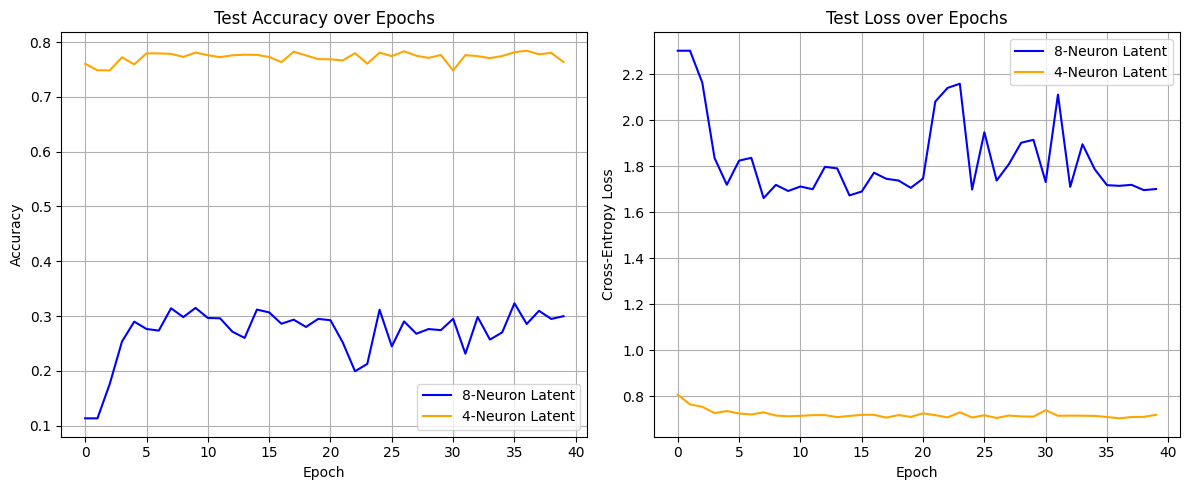

In [5]:
def train_evaluate_classifier(model, X_train_lat, Y_train_oh, X_test_lat, y_test_raw, epochs=40, batch_size=64, lr=0.1):
    m = X_train_lat.shape[0]
    train_losses, test_losses, test_accs = [], [], []
    
    Y_test_oh_local = one_hot(y_test_raw)
    
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_train_lat[indices]
        Y_shuffled = Y_train_oh[indices]
        
        epoch_train_loss = 0
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            Y_batch = Y_shuffled[i:i+batch_size]
            
            # Forward & Train Loss
            out_train = model.forward(X_batch)
            batch_loss = -np.sum(Y_batch * np.log(out_train + 1e-8)) / X_batch.shape[0]
            epoch_train_loss += batch_loss * X_batch.shape[0]
            
            # Backward
            model.backward(X_batch, Y_batch, lr)
            
        epoch_train_loss /= m
        train_losses.append(epoch_train_loss)
        
        # Evaluate on Test Set
        out_test = model.forward(X_test_lat)
        epoch_test_loss = -np.sum(Y_test_oh_local * np.log(out_test + 1e-8)) / X_test_lat.shape[0]
        test_losses.append(epoch_test_loss)
        
        preds = np.argmax(out_test, axis=1)
        epoch_acc = np.mean(preds == y_test_raw)
        test_accs.append(epoch_acc)
        
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_acc*100:.2f}%")
            
    return train_losses, test_losses, test_accs

# Extract latent features
X_test_latent8 = auto8.get_latent(X_test)
X_test_latent4 = auto4.get_latent(X_test)
X_train_latent8 = auto8.get_latent(X_train)
X_train_latent4 = auto4.get_latent(X_train)

print("\n--- Evaluating Feedforward Classifier on 8-Neuron Latent Space ---")
clf8 = Classifier8()
train_L8, test_L8, test_A8 = train_evaluate_classifier(clf8, X_train_latent8, Y_train_oh, X_test_latent8, y_test_raw, epochs=40, batch_size=64, lr=0.1)

print("\n--- Evaluating Feedforward Classifier on 4-Neuron Latent Space ---")
clf4 = Classifier4()
train_L4, test_L4, test_A4 = train_evaluate_classifier(clf4, X_train_latent4, Y_train_oh, X_test_latent4, y_test_raw, epochs=40, batch_size=64, lr=0.1)

# Plotting Results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(test_A8, label='8-Neuron Latent', color='blue')
plt.plot(test_A4, label='4-Neuron Latent', color='orange')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_L8, label='8-Neuron Latent', color='blue')
plt.plot(test_L4, label='4-Neuron Latent', color='orange')
plt.title('Test Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()